<a href="https://colab.research.google.com/github/elabuait/ELABUAIT_HW3_Q1/blob/main/Deep_Learning_Course_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install contractions==0.1.73

import os
import re
import string
import time
import urllib.request
import unicodedata
import pandas as pd
import numpy as np
import datasets
from datasets import (load_dataset,load_from_disk,concatenate_datasets,DatasetDict,ClassLabel,Image as HFImage)
import contractions
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,f1_score)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
from torchvision import transforms, models
from PIL import Image
from transformers import (AutoTokenizer,AutoModelForSequenceClassification,Trainer,TrainingArguments,CLIPProcessor,CLIPModel)
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
import seaborn as sns
from tqdm import tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Path where we will save it
save_path = '/content/drive/MyDrive/HATEFUL_MEMES/hateful_memes_project'

# Only download if it doesn't exist already
if not os.path.exists(save_path):
    print("Downloading and saving to Drive (this takes a few minutes)...")
    # Load without streaming to get the full files
    ds_train = load_dataset("Multimodal-Fatima/Hatefulmemes_train", split="train")
    ds_test = load_dataset("Multimodal-Fatima/Hatefulmemes_test", split="test")
    ds_val = load_dataset("Multimodal-Fatima/Hatefulmemes_validation", split="validation")

    # Standardize the column name if it differs (some use 'image' vs 'img')
    def standardize(ds):
      if 'image' in ds.column_names:
        return ds.rename_column("image", "img").cast_column("img", HFImage())
      return ds.cast_column("img", HFImage())

    ds_train = standardize(ds_train)
    ds_test = standardize(ds_test)
    ds_val = standardize(ds_val)

    # Combine into one DatasetDict.
    ds = DatasetDict({
      "train": ds_train,
      "test": ds_test,
      "validation": ds_val
    })

    # Remove all the unnecessary features.
    keep_features = ['img', 'text', 'label', 'id']

    for split in ds.keys():
      ds[split] = ds[split].select_columns(keep_features)

    #Save the ds on our Drive.
    ds.save_to_disk(save_path)
    print("Done! It's safe on your Drive now.")

# If the Dataset already exists, ignore all the previous code.
else:
    ds = load_from_disk(save_path)
    print("Dataset already exists on Drive. Loading...")

Dataset already exists on Drive. Loading...


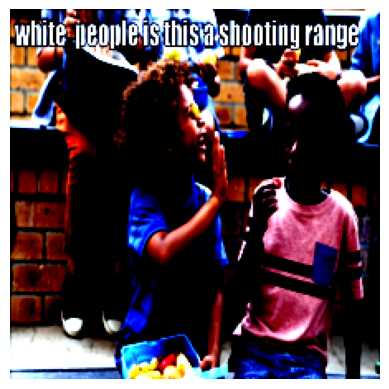

white people is this a shooting range
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


In [ ]:
# Resizes all images to 224x224 and turns them into tensors.
resizer = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

def preprocess_image(example):
  if 'img' in example:
    example['img'] = [resizer(img.convert("RGB")) for img in example['img']]
  return example

ds.set_transform(preprocess_image)

img_tensor = ds['validation'][0]['img']
plt.imshow(img_tensor.permute(1, 2, 0).clip(0, 1))
plt.axis('off')
plt.show()

print(ds['validation'][0]['text'])
print(ds['validation'][0]['img'].shape)
print(ds['validation'][1]['img'].shape)

In [ ]:
display(ds)

DatasetDict({
    train: Dataset({
        features: ['img', 'text', 'label', 'id'],
        num_rows: 8500
    })
    test: Dataset({
        features: ['img', 'text', 'label', 'id'],
        num_rows: 1000
    })
    validation: Dataset({
        features: ['img', 'text', 'label', 'id'],
        num_rows: 500
    })
})

In [ ]:
# We do not want to do class balancing because this dataset contains benign confounders.

label_counts = pd.Series(ds['train']['label']).value_counts()
print("Class Distribution in Training Set:")
print(label_counts)

Class Distribution in Training Set:
0    5481
1    3019
Name: count, dtype: int64


In [ ]:
# The label column of the validation set was, weirdly, not aligned with the other 2.

standard_labels = ClassLabel(num_classes=2, names=['not-hateful', 'hateful'])

ds['validation'] = ds['validation'].cast_column('label', standard_labels)

In [ ]:
for split in ['train', 'validation', 'test']:
    print(f"{split} features: {ds[split].features['label']}")

train features: ClassLabel(names=['not-hateful', 'hateful'])
validation features: ClassLabel(names=['not-hateful', 'hateful'])
test features: ClassLabel(names=['not-hateful', 'hateful'])


In [ ]:
def preprocess_text(post):
    # Normalize unicode
    post = unicodedata.normalize('NFKC', post)

    # Lowercase
    post = post.lower()

    # Expand contractions
    post = contractions.fix(post)

    # Extract and remove hashtags
    hashtags = re.findall(r'#(\w+)', post)
    post = re.sub(r'#\w+', '', post)

    # Extract and remove URLs
    url_pattern = r'https?://\S+|www\.\S+'
    urls = re.findall(url_pattern, post)
    post = re.sub(url_pattern, '', post)

    # Remove mentions
    post = re.sub(r'@\w+', '', post)

    # Normalize elongated words (looooser → looser)
    post = re.sub(r'(.)\1{2,}', r'\1\1', post)

    # Remove standalone numbers but keep hate-coded combinations
    post = re.sub(r'\b\d+\b', '', post)

    # Remove most punctuation but keep ! and ?
    post = re.sub(r'[^\w\s!?]', '', post)

    # Normalize whitespace
    post = " ".join(post.split())

    return post, hashtags, urls

In [ ]:
def map_preprocessing(batch):
    # Process the list of text in the batch
    results = [preprocess_text(t) for t in batch['text']]

    # Unzip the results into three separate lists
    cleaned_texts, hashtags, urls = zip(*results)

    return {
        'cleaned_text': list(cleaned_texts),
        'hashtags': list(hashtags),
        'urls': list(urls)
    }

# Apply to all splits (train, test, validation)
# batched=True makes this significantly faster
ds = ds.map(map_preprocessing, batched=True)

# Quick check to see it worked
print(ds['train'][0]['cleaned_text'])
print(ds['train'][0]['hashtags'])

its their character not their color that matters
[]


In [ ]:
def train_simple_network(model, loss_func, training_loader, epochs=20, device="cpu"):
    #Yellow step is done here. We create the optimizer and move the model to the compute device
    #SGD is Stochastic Gradient Decent over the parameters $\Theta$
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

    #Place the model on the correct compute resource (CPU or GPU)
    model.to(device)
    epoch_losses = []

    #The next two for loops handle the Red steps, iterating through all the data (batches) multiple times (epochs)
    for epoch in tqdm(range(epochs), desc="Epoch"):

        # Unfreeze at Epoch 5
        if epoch == 5:
            print("\nUnfreezing last ResNet blocks for fine-tuning...")
            # We unfreeze the last 2 child blocks of the ResNet stream
            for param in model.visual_stream[5:].parameters():
                param.requires_grad = True
            # Lower the learning rate so we don't "break" the pre-trained weights
            for g in optimizer.param_groups:
                g['lr'] = 1e-5

        model.train() #Put our model in training mode
        running_loss = 0.0

        for images, text_vecs, labels in tqdm(training_loader, desc="Batch", leave=False):
            # Extract the images and labels from the batch dictionary
            images = images.to(device)
            text_vecs = text_vecs.to(device)
            labels = labels.to(device)

            #First a yellow step, prepare the optimizer. Most PyTorch code will do this first to make sure everything is in a clean and ready state.

            #PyTorch stores gradients in a mutable data structure. So we need to set it to a clean state before we use it.
            #Otherwise, it will have old information from a previous iteration
            optimizer.zero_grad()

            #The next two lines of code perform the two blue steps
            y_hat = model(images, text_vecs) #this just computed $f_\theta(\boldsymbol{x_i})

            # Compute loss.
            loss = loss_func(y_hat, labels)

            #Now the remaining two yellow steps, compute the gradient and ".step()" the optimizer
            loss.backward()# $\nabla_\Theta$ just got computed by this one call

            # Gradient Clipping - Prevents the model from making huge, erratic weight changes.
            #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            #Now we just need to update all the parameters
            optimizer.step()# $\Theta_{k+1} = \Theta_k − \eta \cdot \nabla_\Theta \ell(\hat{y}, y)$

            #Now we are just grabbing some information we would like to have
            running_loss += loss.item()
        epoch_loss = running_loss / len(training_loader)
        epoch_losses.append(epoch_loss)

        print(f"Epoch {epoch+1}: {epoch_loss}")
    return epoch_losses
        #if epoch==1:
          #print(y_hat, nn.functional.softmax(y_hat, dim=1))
          #break

In [ ]:
class LateFusionMemeModel(nn.Module):
  def __init__(self):
    super(LateFusionMemeModel, self).__init__()

    # Visual Stream: ResNet-50 (CNN)
    resnet = models.resnet50(weights='IMAGENET1K_V1')
    self.visual_stream = nn.Sequential(*list(resnet.children())[:-1]) # Features only

    # Freezes the CNN.
    # This prevents the model from "forgetting" how to see while it's learning the text.
    for param in self.visual_stream.parameters():
        param.requires_grad = False

    # Textual Stream: Projection for SentenceTransformer (384 dims)
    self.text_projection = nn.Sequential(
        nn.Linear(384, 512),
        nn.ReLU()
    )

    # Fusion Layer: Joins 2048 (Img) + 512 (Text) = 2560
    self.classifier = nn.Sequential(
    nn.Linear(2560, 1024),
    nn.BatchNorm1d(1024), # Stabilizes the learning process
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Linear(512, 2)
    )

  def forward(self, img, text_emb):
    img_feats = torch.flatten(self.visual_stream(img), 1)
    txt_feats = self.text_projection(text_emb)

    # LATE FUSION: Concatenate vectors
    combined = torch.cat((img_feats, txt_feats), dim=1)
    return self.classifier(combined)

In [ ]:
class MiddleFusionMemeModel(nn.Module):
    def __init__(self):
        super(MiddleFusionMemeModel, self).__init__()

        # Visual Stream (ResNet-50)
        resnet = models.resnet50(weights='IMAGENET1K_V1')
        self.visual_stream = nn.Sequential(*list(resnet.children())[:-1])

        # Freeze by default (Stage 1)
        for param in self.visual_stream.parameters():
            param.requires_grad = False

        # Textual Stream (384 -> 512)
        self.text_projection = nn.Sequential(
            nn.Linear(384, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # Middle Fusion Layer (The "Interaction Brain")
        # Instead of going straight to 2 classes, we let them "mingle"
        # through multiple deep layers to find those benign confounder links.
        self.fusion_brain = nn.Sequential(
            nn.Linear(2048 + 512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 2) # Final Binary Classification
        )

    def forward(self, img, text_emb):
        # Extract visual features (2048 dims)
        img_feats = torch.flatten(self.visual_stream(img), 1)

        # Extract textual features (512 dims)
        txt_feats = self.text_projection(text_emb)

        # Merge them "in the middle"
        combined = torch.cat((img_feats, txt_feats), dim=1)

        # Let the deep fusion brain look for patterns between the two
        return self.fusion_brain(combined)


In [ ]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')

print("Encoding text... please wait.")
train_text_vecs = torch.tensor(
    embedder.encode(ds['train']['cleaned_text']),
    dtype=torch.float32
)
val_text_vecs = torch.tensor(
    embedder.encode(ds['validation']['cleaned_text']),
    dtype=torch.float32
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding text... please wait.


In [ ]:
model = MiddleFusionMemeModel()
device = "cuda" if torch.cuda.is_available() else "cpu"

# The dataset is roughly 60/40.
# We give the 'Hateful' class (index 1) a higher weight (e.g., 1.5 or 2.0)
# to force the model to pay more attention to it.
weights = torch.tensor([1.0, 1.8]).to(device)
#loss_func = nn.CrossEntropyLoss(weight=weights,label_smoothing=0.1)
loss_func = nn.CrossEntropyLoss(weight=weights)

class MemeDataset(Dataset):

    def __init__(self, hf_dataset, text_embeddings):
        self.dataset = hf_dataset
        self.text_embeddings = text_embeddings

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        image = self.dataset[idx]['img']
        label = self.dataset[idx]['label']
        text_vec = self.text_embeddings[idx]

        return image, text_vec, torch.tensor(label)

train_dataset = MemeDataset(ds['train'], train_text_vecs)
val_dataset = MemeDataset(ds['validation'], val_text_vecs)

#small_dataset = Subset(train_dataset, range(3000))
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,      # Uses multiple CPU cores
    pin_memory=True,    # Speeds up transfer from CPU to GPU
    persistent_workers=True # Keeps workers alive between epochs
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

losses = train_simple_network(
    model,
    loss_func,
    train_loader,
    epochs=10,
    device=device
)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 316MB/s]
Epoch:  10%|█         | 1/10 [02:31<22:45, 151.76s/it]

Epoch 1: 0.6115742695510835



Epoch:  20%|██        | 2/10 [03:37<13:30, 101.31s/it]

Epoch 2: 0.5174263508472228


...

Epoch 8: 0.19992056021228768



Epoch:  90%|█████████ | 9/10 [11:21<01:07, 67.61s/it]

Epoch 9: 0.15131216513034992



Epoch: 100%|██████████| 10/10 [12:27<00:00, 74.73s/it]

Epoch 10: 0.1297029647415966


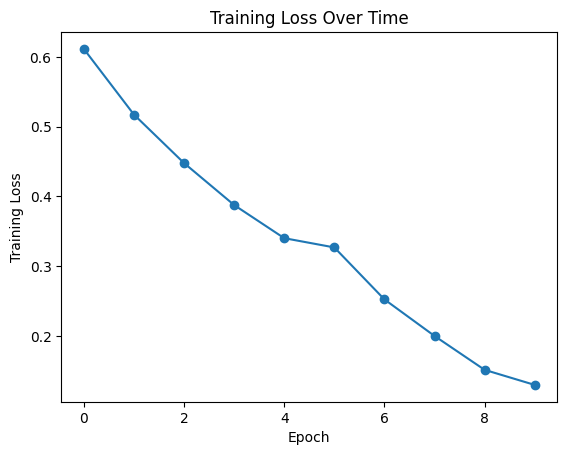

In [ ]:
plt.figure()
plt.plot(losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Time")
plt.show()

In [ ]:
def evaluate_model(model, dataloader, device="cpu"):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, text_vecs, labels in dataloader:

            images = images.to(device)
            text_vecs = text_vecs.to(device)

            outputs = model(images, text_vecs)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

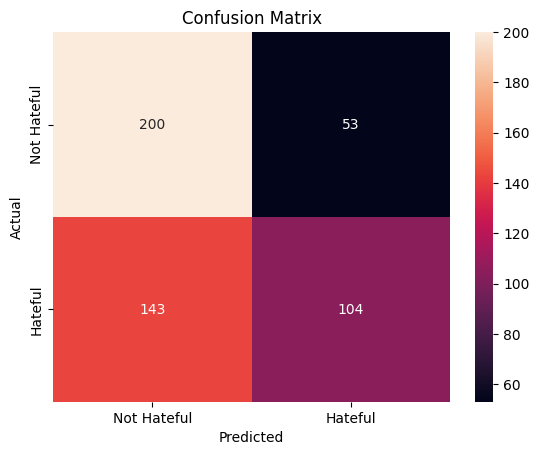

In [ ]:
preds, labels = evaluate_model(model, val_loader, device)

cm = confusion_matrix(labels, preds)

plt.figure()

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Hateful","Hateful"],
    yticklabels=["Not Hateful","Hateful"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
accuracy = (preds == labels).mean()

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.608


In [ ]:
print(ds['train'].column_names)

['img', 'text', 'label', 'id', 'cleaned_text', 'hashtags', 'urls']


EXTRA TESTS

1.   BOW(Bag of Words)
2.   fine tuning pretrained model(distilbert)
3.   CLIP model fine tuning


In [ ]:
vectorizer = CountVectorizer(
    max_features=20000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.9
)

X_train = vectorizer.fit_transform(ds['train']['text'])
X_val = vectorizer.transform(ds['validation']['text'])

y_train = ds['train']['label']
y_val = ds['validation']['label']

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

preds = clf.predict(X_val)

print("BOW Accuracy:", accuracy_score(y_val, preds))
print(classification_report(y_val, preds))

BOW Accuracy: 0.56
              precision    recall  f1-score   support

           0       0.54      0.86      0.66       253
           1       0.64      0.26      0.36       247

    accuracy                           0.56       500
   macro avg       0.59      0.56      0.51       500
weighted avg       0.59      0.56      0.52       500



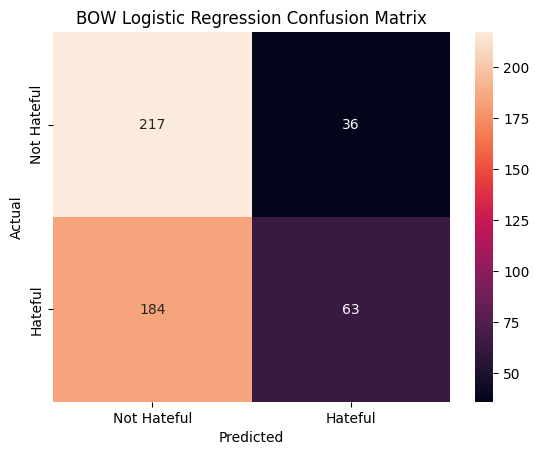

In [ ]:
cm = confusion_matrix(y_val, preds)

plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Hateful", "Hateful"],
    yticklabels=["Not Hateful", "Hateful"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BOW Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
!pip install transformers datasets evaluate
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2


)
def tokenize(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=128)

tokenized_ds = ds.map(tokenize, batched=True)

tokenized_ds.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask', 'label']
)
training_args = TrainingArguments(
    output_dir="./bert_results",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=20,
    learning_rate=2e-5,
    weight_decay=0.01
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = torch.argmax(torch.tensor(logits), axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds['train'],
    eval_dataset=tokenized_ds['validation'],
    compute_metrics=compute_metrics  # keep metrics
)
trainer.train()
results = trainer.evaluate(tokenized_ds['validation'])
print(results)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 2.9114720821380615, 'eval_accuracy': 0.56, 'eval_f1': 0.375, 'eval_precision': 0.6285714285714286, 'eval_recall': 0.26720647773279355, 'eval_runtime': 2.3767, 'eval_samples_per_second': 210.373, 'eval_steps_per_second': 13.464, 'epoch': 20.0}


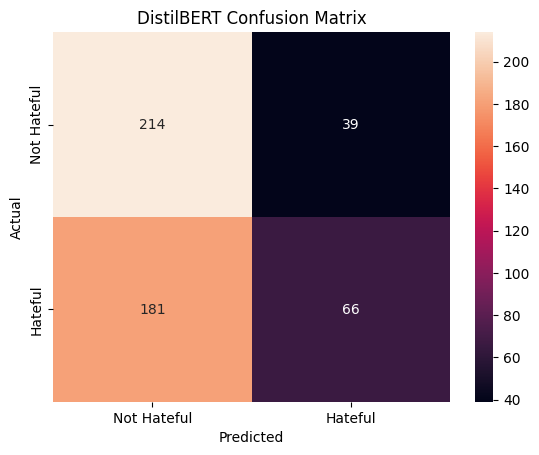

In [ ]:
pred_output = trainer.predict(tokenized_ds['validation'])

bert_preds = np.argmax(pred_output.predictions, axis=1)
bert_labels = pred_output.label_ids

cm = confusion_matrix(bert_labels, bert_preds)

plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Hateful", "Hateful"],
    yticklabels=["Not Hateful", "Hateful"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT Confusion Matrix")
plt.show()

In [ ]:
ds.reset_format()
ds = ds.cast_column("img", datasets.Image())

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

class MemeCLIPDataset(Dataset):
    def __init__(self, hf_dataset):
        self.dataset = hf_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image = self.dataset[idx]['img']
        text = self.dataset[idx]['cleaned_text']
        label = self.dataset[idx]['label']

        inputs = processor(
            text=[text],
            images=[image],
            return_tensors="pt",
            padding=True,
            truncation=True
        )

        for k in inputs:
            inputs[k] = inputs[k].squeeze(0)

        return inputs, torch.tensor(label)
from torch.nn.utils.rnn import pad_sequence

def collate_clip(batch):
    input_ids = [item[0]['input_ids'] for item in batch]
    attention_mask = [item[0]['attention_mask'] for item in batch]
    pixel_values = [item[0]['pixel_values'] for item in batch]
    labels = torch.stack([item[1] for item in batch])

    input_ids = pad_sequence(input_ids, batch_first=True, padding_value=processor.tokenizer.pad_token_id)
    attention_mask = pad_sequence(attention_mask, batch_first=True, padding_value=0)

    pixel_values = torch.stack(pixel_values)

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'pixel_values': pixel_values
    }, labels

train_dataset = MemeCLIPDataset(ds['train'])
val_dataset   = MemeCLIPDataset(ds['validation'])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_clip)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, collate_fn=collate_clip)


class CLIPClassifier(nn.Module):
    def __init__(self, clip_model):
        super(CLIPClassifier, self).__init__()
        self.clip = clip_model
        for param in self.clip.parameters():
            param.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Linear(512 + 512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

    def forward(self, input_ids, attention_mask, pixel_values):
        text_embeds = self.clip.get_text_features(
            input_ids=input_ids, attention_mask=attention_mask
        )
        img_embeds = self.clip.get_image_features(pixel_values=pixel_values)
        combined = torch.cat((text_embeds, img_embeds), dim=1)
        return self.classifier(combined)

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model = CLIPClassifier(clip_model).to(device)


weights = torch.tensor([1.0, 2.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)


epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for batch in tqdm(train_loader):
        inputs, labels = batch
        for k in inputs:
            inputs[k] = inputs[k].to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            pixel_values=inputs['pixel_values']
        )

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1}: {running_loss / len(train_loader):.4f}")


    if epoch == 2:
        print("Unfreezing last 2 CLIP transformer layers for fine-tuning...")
        for name, param in model.clip.text_model.encoder.layers[-2:].named_parameters():
            param.requires_grad = True
        for name, param in model.clip.vision_model.encoder.layers[-2:].named_parameters():
            param.requires_grad = True
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)


model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in val_loader:
        inputs, labels = batch
        for k in inputs:
            inputs[k] = inputs[k].to(device)
        labels = labels.to(device)

        outputs = model(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            pixel_values=inputs['pixel_values']
        )
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
print(f"Validation Accuracy: {accuracy:.3f}, F1: {f1:.3f}")

Device: cuda


100%|██████████| 532/532 [06:52<00:00,  1.29it/s]


Epoch 1: 0.6065


100%|██████████| 532/532 [06:05<00:00,  1.46it/s]


Epoch 2: 0.5313


...

Epoch 3: 0.4958
Unfreezing last 2 CLIP transformer layers for fine-tuning...


100%|██████████| 532/532 [06:07<00:00,  1.45it/s]


Epoch 4: 0.4683


100%|██████████| 532/532 [06:08<00:00,  1.44it/s]


Epoch 5: 0.3249
Validation Accuracy: 0.640, F1: 0.567


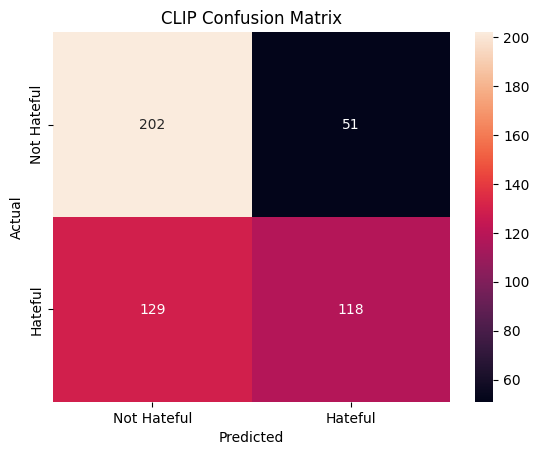

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Hateful", "Hateful"],
    yticklabels=["Not Hateful", "Hateful"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CLIP Confusion Matrix")
plt.show()